# 04 - Model Training and Trust Layer

In this notebook, we train churn prediction models using the final customer-level feature dataset created in Notebook 03.

The goal is not only to build a model, but also to evaluate whether the model is trustworthy for retention decisions using classification metrics, lift analysis, calibration, and feature importance.

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
# Connecting notebook to project folders

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/LoyaltyRadar")

PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "data" / "outputs"
FIGURE_DIR = BASE_DIR / "reports" / "figures"
MODEL_DIR = BASE_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [3]:
# Loading final customer feature dataset

df = pd.read_csv(PROCESSED_DIR / "03_final_customer_features.csv")

print("Dataset shape:", df.shape)
print("Unique customers:", df["loyalty_number"].nunique())

display(df.head())

Dataset shape: (16737, 50)
Unique customers: 16737


,loyalty_number,target_churn,behavioral_churn,formal_churn,churn_status_group,months_present,total_flights,active_months,inactive_months,active_month_rate,avg_flights_per_active_month,total_distance,flights_last_3m,flights_last_6m,points_accumulated_last_6m,points_redeemed_last_6m,inactive_last_3m,inactive_last_6m,flights_first_half_2018,flights_second_half_2018,flight_drop,flight_drop_pct,sharp_drop_flag,q1_flights,q2_flights,q3_flights,q4_flights,seasonality_ratio,seasonal_flag,total_points_accumulated,total_points_redeemed,redemption_months,has_redeemed,redemption_rate,points_collector_flag,clv,clv_tier,high_value_flag,premium_value_flag,loyalty_value_at_risk,retention_priority_score,priority_band,loyalty_card,province,city,gender,education,salary_imputed,salary_missing,enrollment_type
0,100018,0,0,0,Healthy Active,24,46,18,6,0.750000,2.555556,81190,10,17,36377.0,385,0,0,5.0,17.0,-12.0,-2.400000,0,9,3,16,18,0.391304,0,81190.0,1513,3,True,0.018635,1,7919.20,High Value,1,0,0.0,10,Low Priority,Aurora,Alberta,Edmonton,Female,Bachelor,92552.0,0,Standard
1,100102,0,0,0,Healthy Active,24,51,17,7,0.708333,3.000000,68918,11,17,18795.0,0,0,0,9.0,17.0,-8.0,-0.888889,0,10,10,13,18,0.352941,0,68918.0,1195,2,True,0.017339,1,2887.74,Low Value,0,0,0.0,10,Low Priority,Nova,Ontario,Toronto,Male,College,73455.0,1,Standard
2,100140,0,0,0,Healthy Active,24,47,17,7,0.708333,2.764706,72856,3,11,20488.0,0,0,0,14.0,11.0,3.0,0.214286,0,9,13,15,10,0.319149,0,72856.0,593,1,True,0.008139,1,2838.07,Low Value,0,0,0.0,10,Low Priority,Nova,British Columbia,Dawson Creek,Female,College,73455.0,1,Standard
3,100214,0,0,0,Healthy Active,24,22,9,15,0.375000,2.444444,38236,3,9,14321.0,0,0,0,3.0,9.0,-6.0,-2.000000,0,3,2,8,9,0.409091,0,38236.0,861,2,True,0.022518,0,4170.57,Mid Value,0,0,0.0,0,Low Priority,Star,British Columbia,Vancouver,Male,Bachelor,63253.0,0,Standard
4,100272,0,0,0,Healthy Active,24,37,13,11,0.541667,2.846154,54997,4,9,16412.0,0,0,0,8.0,9.0,-1.0,-0.125000,0,7,15,7,8,0.405405,0,54997.0,1007,2,True,0.018310,1,6622.05,High Value,1,0,0.0,10,Low Priority,Star,Ontario,Toronto,Female,Bachelor,91163.0,0,Standard


In [4]:
# Separating target and leakage-safe modelling features

target_col = "target_churn"

leakage_cols = [
    "loyalty_number",
    "target_churn",
    "behavioral_churn",
    "inactive_last_6m",
    "flights_last_6m",
    "churn_status_group",
    "loyalty_value_at_risk",
    "retention_priority_score",
    "priority_band"
]

X = df.drop(columns=leakage_cols)
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts(normalize=True).round(3) * 100)

X shape: (16737, 41)
y shape: (16737,)

Target distribution:


,proportion
target_churn,
0,85.2
1,14.8


In [5]:
# Identifying numerical and categorical columns

numeric_cols = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Number of numeric columns: 34
Number of categorical columns: 7

Numeric columns:
['formal_churn', 'months_present', 'total_flights', 'active_months', 'inactive_months', 'active_month_rate', 'avg_flights_per_active_month', 'total_distance', 'flights_last_3m', 'points_accumulated_last_6m', 'points_redeemed_last_6m', 'inactive_last_3m', 'flights_first_half_2018', 'flights_second_half_2018', 'flight_drop', 'flight_drop_pct', 'sharp_drop_flag', 'q1_flights', 'q2_flights', 'q3_flights', 'q4_flights', 'seasonality_ratio', 'seasonal_flag', 'total_points_accumulated', 'total_points_redeemed', 'redemption_months', 'has_redeemed', 'redemption_rate', 'points_collector_flag', 'clv', 'high_value_flag', 'premium_value_flag', 'salary_imputed', 'salary_missing']

Categorical columns:
['clv_tier', 'loyalty_card', 'province', 'city', 'gender', 'education', 'enrollment_type']


In [6]:
# Removing formal churn from model input to avoid target/status leakage

X = X.drop(columns=["formal_churn"])

numeric_cols = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Updated X shape:", X.shape)

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

Updated X shape: (16737, 40)
Number of numeric columns: 33
Number of categorical columns: 7


formal_churn is also an outcome/status variable.
In a real retention prediction system, we would not know future/formal churn for customers we want to score.

In [7]:
# Splitting data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3) * 100)

X_train shape: (13389, 40)
X_test shape: (3348, 40)

Train target distribution:
target_churn
0    85.2
1    14.8
Name: proportion, dtype: float64

Test target distribution:
target_churn
0    85.2
1    14.8
Name: proportion, dtype: float64


Observation:
The data was split into training and testing sets using stratified sampling. Both train and test sets preserve the same target churn distribution of 14.8%, which is important because the target is moderately imbalanced. This ensures that model evaluation on the test set remains representative of the overall customer base.

In [8]:
# Building preprocessing pipeline for numerical and categorical columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [9]:
# Creating reusable model evaluation function

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Predicting class labels
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Predicting probabilities for churn class
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,

        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),

        "train_precision": precision_score(y_train, y_train_pred, zero_division=0),
        "test_precision": precision_score(y_test, y_test_pred, zero_division=0),

        "train_recall": recall_score(y_train, y_train_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_test_pred, zero_division=0),

        "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_test_pred, zero_division=0),

        "train_roc_auc": roc_auc_score(y_train, y_train_proba),
        "test_roc_auc": roc_auc_score(y_test, y_test_proba),

        "train_pr_auc": average_precision_score(y_train, y_train_proba),
        "test_pr_auc": average_precision_score(y_test, y_test_proba)
    }

    return metrics

In [10]:
# Training baseline dummy model

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model.fit(X_train, y_train)

baseline_metrics = evaluate_model(
    "Baseline Dummy",
    baseline_model,
    X_train,
    X_test,
    y_train,
    y_test
)

baseline_metrics

{'model': 'Baseline Dummy',
 'train_accuracy': 0.8524908506983344,
 'test_accuracy': 0.8524492234169654,
 'train_precision': 0.0,
 'test_precision': 0.0,
 'train_recall': 0.0,
 'test_recall': 0.0,
 'train_f1': 0.0,
 'test_f1': 0.0,
 'train_roc_auc': np.float64(0.5),
 'test_roc_auc': np.float64(0.5),
 'train_pr_auc': np.float64(0.14750914930166556),
 'test_pr_auc': np.float64(0.14755077658303464)}

Observation:
The baseline dummy model achieves around 85.2% test accuracy by predicting every customer as non-churn. However, it has zero precision, zero recall, and zero F1-score for the churn class, meaning it fails to identify any at-risk customers. This confirms that accuracy is misleading for this moderately imbalanced churn problem. Better models should be evaluated using recall, precision, F1-score, ROC-AUC, PR-AUC, and lift.

In [11]:
# Training logistic regression model

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_metrics = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test
)

logistic_metrics

{'model': 'Logistic Regression',
 'train_accuracy': 0.9973112256329822,
 'test_accuracy': 0.996415770609319,
 'train_precision': 0.982098458478369,
 'test_precision': 0.9762845849802372,
 'train_recall': 1.0,
 'test_recall': 1.0,
 'train_f1': 0.9909683893627697,
 'test_f1': 0.988,
 'train_roc_auc': np.float64(0.9999909061268307),
 'test_roc_auc': np.float64(0.9999588616303845),
 'train_pr_auc': np.float64(0.999947239282204),
 'test_pr_auc': np.float64(0.9997624830601604)}

Observation:
The first logistic regression model produced near-perfect test performance, which is a warning sign of data leakage. Since the target churn label is based on inactivity in the last 6 months, features such as recent flights, inactive months, second-half 2018 activity, and quarterly activity can directly or indirectly reveal the target. Therefore, the modelling setup must be redesigned using a temporal split: features should be built only from the observation period before the churn window.

In [12]:
# Creating temporal observation and target windows

df_monthly = pd.read_csv(PROCESSED_DIR / "02_customer_month_base.csv")
df_monthly["activity_date"] = pd.to_datetime(df_monthly["activity_date"])

observation_end = pd.Timestamp("2018-06-01")
target_start = pd.Timestamp("2018-07-01")
target_end = pd.Timestamp("2018-12-01")

observation_df = df_monthly[df_monthly["activity_date"] <= observation_end].copy()
target_df = df_monthly[
    (df_monthly["activity_date"] >= target_start) &
    (df_monthly["activity_date"] <= target_end)
].copy()

print("Observation period:", observation_df["activity_date"].min(), "to", observation_df["activity_date"].max())
print("Target period:", target_df["activity_date"].min(), "to", target_df["activity_date"].max())

print("Observation shape:", observation_df.shape)
print("Target shape:", target_df.shape)

Observation period: 2017-01-01 00:00:00 to 2018-06-01 00:00:00
Target period: 2018-07-01 00:00:00 to 2018-12-01 00:00:00
Observation shape: (288643, 31)
Target shape: (100422, 31)


In [13]:
# Building customer features only from observation period

safe_features = (
    observation_df
    .groupby("loyalty_number")
    .agg(
        months_present_obs=("activity_date", "nunique"),
        total_flights_obs=("total_flights", "sum"),
        active_months_obs=("total_flights", lambda x: (x > 0).sum()),
        total_distance_obs=("distance", "sum"),
        total_points_accumulated_obs=("points_accumulated", "sum"),
        total_points_redeemed_obs=("points_redeemed", "sum")
    )
    .reset_index()
)

safe_features["inactive_months_obs"] = (
    safe_features["months_present_obs"] - safe_features["active_months_obs"]
)

safe_features["active_month_rate_obs"] = (
    safe_features["active_months_obs"] / safe_features["months_present_obs"]
)

safe_features["avg_flights_per_active_month_obs"] = (
    safe_features["total_flights_obs"] /
    safe_features["active_months_obs"].replace(0, np.nan)
).fillna(0)

display(safe_features.head())

,loyalty_number,months_present_obs,total_flights_obs,active_months_obs,total_distance_obs,total_points_accumulated_obs,total_points_redeemed_obs,inactive_months_obs,active_month_rate_obs,avg_flights_per_active_month_obs
0,100018,18,29,13,44813,44813.0,1128,5,0.722222,2.230769
1,100102,18,34,12,50123,50123.0,1195,6,0.666667,2.833333
2,100140,18,36,13,52368,52368.0,593,5,0.722222,2.769231
3,100214,18,13,6,23915,23915.0,861,12,0.333333,2.166667
4,100272,18,28,10,38585,38585.0,1007,8,0.555556,2.800000


In [14]:
# Creating future churn target from Jul-Dec 2018 activity

future_target = (
    target_df
    .groupby("loyalty_number")
    .agg(
        future_flights_6m=("total_flights", "sum"),
        future_points_accumulated_6m=("points_accumulated", "sum"),
        future_points_redeemed_6m=("points_redeemed", "sum")
    )
    .reset_index()
)

future_target["target_churn"] = (
    future_target["future_flights_6m"] == 0
).astype(int)

display(future_target["target_churn"].value_counts(normalize=True).round(3) * 100)

,proportion
target_churn,
0,85.2
1,14.8


In [15]:
# Adding customer profile and value features

profile_cols = [
    "loyalty_number",
    "clv",
    "loyalty_card",
    "province",
    "city",
    "gender",
    "education",
    "salary",
    "enrollment_type",
    "formal_churn"
]

customer_profile_safe = (
    df_monthly[profile_cols]
    .drop_duplicates("loyalty_number")
    .copy()
)

customer_profile_safe["salary_missing"] = customer_profile_safe["salary"].isnull().astype(int)

salary_median = customer_profile_safe["salary"].median()
customer_profile_safe["salary_imputed"] = customer_profile_safe["salary"].fillna(salary_median)

safe_model_df = safe_features.merge(
    future_target[["loyalty_number", "target_churn"]],
    on="loyalty_number",
    how="inner"
)

safe_model_df = safe_model_df.merge(
    customer_profile_safe.drop(columns=["salary"]),
    on="loyalty_number",
    how="left"
)

print("Safe modelling dataset shape:", safe_model_df.shape)
print("Unique customers:", safe_model_df["loyalty_number"].nunique())
print("Target distribution:")
print(safe_model_df["target_churn"].value_counts(normalize=True).round(3) * 100)

display(safe_model_df.head())

Safe modelling dataset shape: (16737, 21)
Unique customers: 16737
Target distribution:
target_churn
0    85.2
1    14.8
Name: proportion, dtype: float64


,loyalty_number,months_present_obs,total_flights_obs,active_months_obs,total_distance_obs,total_points_accumulated_obs,total_points_redeemed_obs,inactive_months_obs,active_month_rate_obs,avg_flights_per_active_month_obs,target_churn,clv,loyalty_card,province,city,gender,education,enrollment_type,formal_churn,salary_missing,salary_imputed
0,100018,18,29,13,44813,44813.0,1128,5,0.722222,2.230769,0,7919.20,Aurora,Alberta,Edmonton,Female,Bachelor,Standard,0,0,92552.0
1,100102,18,34,12,50123,50123.0,1195,6,0.666667,2.833333,0,2887.74,Nova,Ontario,Toronto,Male,College,Standard,0,1,73455.0
2,100140,18,36,13,52368,52368.0,593,5,0.722222,2.769231,0,2838.07,Nova,British Columbia,Dawson Creek,Female,College,Standard,0,1,73455.0
3,100214,18,13,6,23915,23915.0,861,12,0.333333,2.166667,0,4170.57,Star,British Columbia,Vancouver,Male,Bachelor,Standard,0,0,63253.0
4,100272,18,28,10,38585,38585.0,1007,8,0.555556,2.800000,0,6622.05,Star,Ontario,Toronto,Female,Bachelor,Standard,0,0,91163.0


In [16]:
# Preparing leakage-safe X and y

safe_target_col = "target_churn"

safe_leakage_cols = [
    "loyalty_number",
    "target_churn",
    "formal_churn"
]

X_safe = safe_model_df.drop(columns=safe_leakage_cols)
y_safe = safe_model_df[safe_target_col]

print("X_safe shape:", X_safe.shape)
print("y_safe shape:", y_safe.shape)

display(y_safe.value_counts(normalize=True).round(3) * 100)

X_safe shape: (16737, 18)
y_safe shape: (16737,)


,proportion
target_churn,
0,85.2
1,14.8


In [17]:
# Identifying numerical and categorical columns for safe dataset

safe_numeric_cols = X_safe.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
safe_categorical_cols = X_safe.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric columns:", len(safe_numeric_cols))
print("Number of categorical columns:", len(safe_categorical_cols))

print("\nNumeric columns:")
print(safe_numeric_cols)

print("\nCategorical columns:")
print(safe_categorical_cols)

Number of numeric columns: 12
Number of categorical columns: 6

Numeric columns:
['months_present_obs', 'total_flights_obs', 'active_months_obs', 'total_distance_obs', 'total_points_accumulated_obs', 'total_points_redeemed_obs', 'inactive_months_obs', 'active_month_rate_obs', 'avg_flights_per_active_month_obs', 'clv', 'salary_missing', 'salary_imputed']

Categorical columns:
['loyalty_card', 'province', 'city', 'gender', 'education', 'enrollment_type']


In [18]:
# Splitting safe dataset into train and test sets

X_train_safe, X_test_safe, y_train_safe, y_test_safe = train_test_split(
    X_safe,
    y_safe,
    test_size=0.2,
    random_state=42,
    stratify=y_safe
)

print("X_train_safe shape:", X_train_safe.shape)
print("X_test_safe shape:", X_test_safe.shape)

print("\nTrain target distribution:")
print(y_train_safe.value_counts(normalize=True).round(3) * 100)

print("\nTest target distribution:")
print(y_test_safe.value_counts(normalize=True).round(3) * 100)

X_train_safe shape: (13389, 18)
X_test_safe shape: (3348, 18)

Train target distribution:
target_churn
0    85.2
1    14.8
Name: proportion, dtype: float64

Test target distribution:
target_churn
0    85.2
1    14.8
Name: proportion, dtype: float64


In [19]:
# Building preprocessing pipeline for leakage-safe dataset

safe_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

safe_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

safe_preprocessor = ColumnTransformer(
    transformers=[
        ("num", safe_numeric_transformer, safe_numeric_cols),
        ("cat", safe_categorical_transformer, safe_categorical_cols)
    ]
)

print("Safe preprocessing pipeline created successfully.")

Safe preprocessing pipeline created successfully.


In [20]:
# Training baseline dummy model on leakage-safe data

safe_baseline_model = Pipeline(steps=[
    ("preprocessor", safe_preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

safe_baseline_model.fit(X_train_safe, y_train_safe)

safe_baseline_metrics = evaluate_model(
    "Safe Baseline Dummy",
    safe_baseline_model,
    X_train_safe,
    X_test_safe,
    y_train_safe,
    y_test_safe
)

safe_baseline_metrics

{'model': 'Safe Baseline Dummy',
 'train_accuracy': 0.8524908506983344,
 'test_accuracy': 0.8524492234169654,
 'train_precision': 0.0,
 'test_precision': 0.0,
 'train_recall': 0.0,
 'test_recall': 0.0,
 'train_f1': 0.0,
 'test_f1': 0.0,
 'train_roc_auc': np.float64(0.5),
 'test_roc_auc': np.float64(0.5),
 'train_pr_auc': np.float64(0.14750914930166556),
 'test_pr_auc': np.float64(0.14755077658303464)}

In [21]:
# Training logistic regression on leakage-safe data

safe_logistic_model = Pipeline(steps=[
    ("preprocessor", safe_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

safe_logistic_model.fit(X_train_safe, y_train_safe)

safe_logistic_metrics = evaluate_model(
    "Safe Logistic Regression",
    safe_logistic_model,
    X_train_safe,
    X_test_safe,
    y_train_safe,
    y_test_safe
)

safe_logistic_metrics

{'model': 'Safe Logistic Regression',
 'train_accuracy': 0.8439017103592501,
 'test_accuracy': 0.8387096774193549,
 'train_precision': 0.48347226214429434,
 'test_precision': 0.47325581395348837,
 'train_recall': 0.8516455696202532,
 'test_recall': 0.8238866396761133,
 'train_f1': 0.6167950128346168,
 'test_f1': 0.6011816838995568,
 'train_roc_auc': np.float64(0.8954399992902344),
 'test_roc_auc': np.float64(0.8946134269964167),
 'train_pr_auc': np.float64(0.5271493072733942),
 'test_pr_auc': np.float64(0.5328705809657621)}

Observation:
After rebuilding the modelling setup to avoid temporal leakage, logistic regression produced realistic performance. The model achieved around 89.5% ROC-AUC and 53.3% PR-AUC on the test set, with recall of 82.4% and precision of 47.3%. This suggests that past customer behavior can meaningfully predict future inactivity. Since this is a retention problem, high recall is valuable because the business wants to identify most at-risk customers before they become inactive.

In [22]:
# Training random forest model on leakage-safe data

safe_rf_model = Pipeline(steps=[
    ("preprocessor", safe_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

safe_rf_model.fit(X_train_safe, y_train_safe)

safe_rf_metrics = evaluate_model(
    "Safe Random Forest",
    safe_rf_model,
    X_train_safe,
    X_test_safe,
    y_train_safe,
    y_test_safe
)

safe_rf_metrics

{'model': 'Safe Random Forest',
 'train_accuracy': 0.8259018597356038,
 'test_accuracy': 0.8246714456391876,
 'train_precision': 0.45426515930113054,
 'test_precision': 0.4523076923076923,
 'train_recall': 0.8951898734177215,
 'test_recall': 0.8927125506072875,
 'train_f1': 0.6026930288051815,
 'test_f1': 0.6004084411164057,
 'train_roc_auc': np.float64(0.9186754441026233),
 'test_roc_auc': np.float64(0.8969122107192405),
 'train_pr_auc': np.float64(0.6147842495878709),
 'test_pr_auc': np.float64(0.5364473641721789)}

Observation:
Random Forest achieved similar overall performance to Logistic Regression but with higher recall. It identified around 89.3% of future inactive customers, compared to 82.4% for Logistic Regression, while precision decreased slightly. This trade-off may be useful for retention campaigns where missing at-risk customers is more costly than contacting some extra customers. Both models perform far better than the dummy baseline, confirming that past customer behavior has predictive value.

In [23]:
# Comparing baseline, logistic regression, and random forest models

model_results = pd.DataFrame([
    safe_baseline_metrics,
    safe_logistic_metrics,
    safe_rf_metrics
])

metric_cols = [
    "model",
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc",
    "test_pr_auc"
]

model_comparison = model_results[metric_cols].round(3)

display(model_comparison)

,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,Safe Baseline Dummy,0.852,0.000,0.000,0.000,0.500,0.148
1,Safe Logistic Regression,0.839,0.473,0.824,0.601,0.895,0.533
2,Safe Random Forest,0.825,0.452,0.893,0.600,0.897,0.536


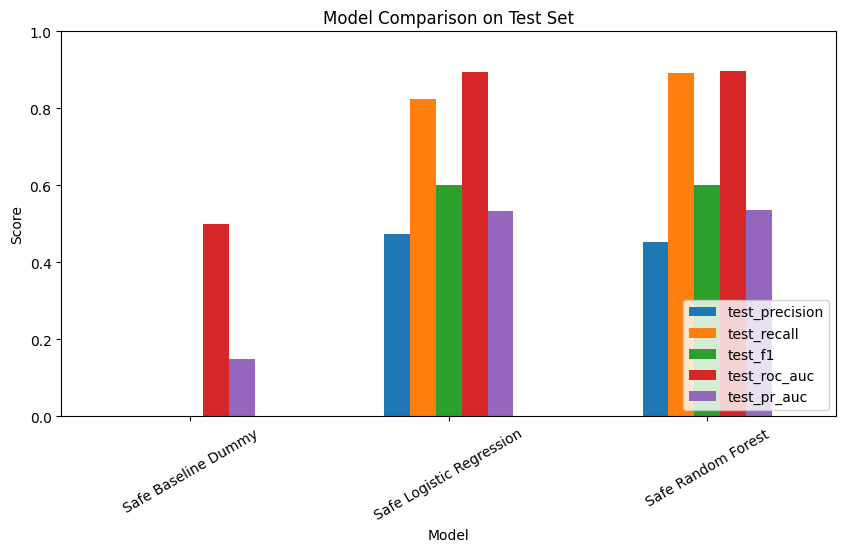

In [24]:
# Plotting model comparison on important test metrics

plot_df = model_comparison.set_index("model")[
    ["test_precision", "test_recall", "test_f1", "test_roc_auc", "test_pr_auc"]
]

plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Model Comparison on Test Set")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

Observation:
The leakage-safe models perform far better than the dummy baseline. The dummy model has high accuracy because it predicts all customers as non-churn, but it completely fails to identify churners. Logistic Regression and Random Forest both achieve around 0.60 F1-score and close to 0.90 ROC-AUC. Random Forest has the highest recall, identifying around 89.3% of future inactive customers, while Logistic Regression has slightly better precision. For retention use cases, Random Forest may be preferred when the goal is to catch as many at-risk customers as possible.

Champion model = Safe Random Forest

In [25]:
# Creating confusion matrix for champion model

champion_model = safe_rf_model
champion_name = "Safe Random Forest"

y_test_pred = champion_model.predict(X_test_safe)
y_test_proba = champion_model.predict_proba(X_test_safe)[:, 1]

cm = confusion_matrix(y_test_safe, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-Churn", "Actual Churn"],
    columns=["Predicted Non-Churn", "Predicted Churn"]
)

display(cm_df)

,Predicted Non-Churn,Predicted Churn
Actual Non-Churn,2320,534
Actual Churn,53,441


In [26]:
# Showing classification report for champion model

print(classification_report(y_test_safe, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.81      0.89      2854
           1       0.45      0.89      0.60       494

    accuracy                           0.82      3348
   macro avg       0.71      0.85      0.74      3348
weighted avg       0.90      0.82      0.85      3348



Observation:
The champion Random Forest model correctly identified 441 out of 494 future inactive customers in the test set, giving high churn recall. Only 53 churn-risk customers were missed. However, the model also flagged 534 non-churn customers as at-risk, showing a precision trade-off. For a retention use case, this trade-off can be acceptable because the business may prefer contacting some extra customers rather than missing customers likely to become inactive.

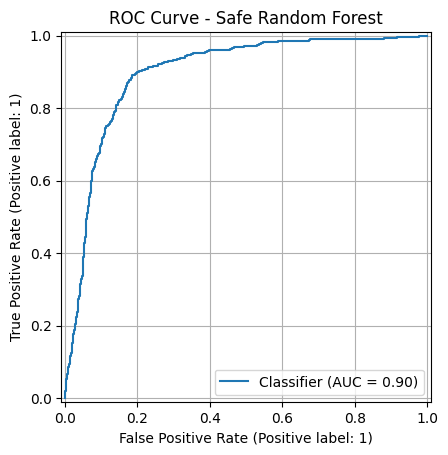

In [27]:
# Plotting ROC curve for champion model

RocCurveDisplay.from_predictions(y_test_safe, y_test_proba)

plt.title("ROC Curve - Safe Random Forest")
plt.grid(True)
plt.show()

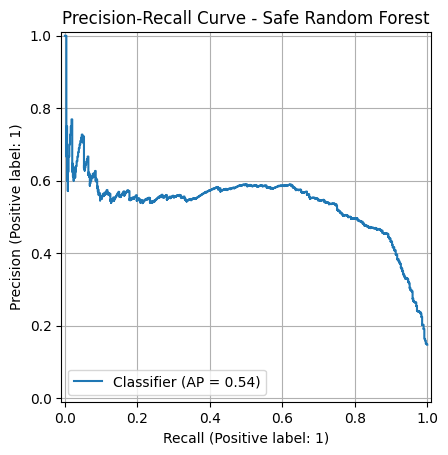

In [28]:
# Plotting Precision-Recall curve for champion model

PrecisionRecallDisplay.from_predictions(y_test_safe, y_test_proba)

plt.title("Precision-Recall Curve - Safe Random Forest")
plt.grid(True)
plt.show()

Observation:
The ROC curve shows that the model separates future inactive and active customers well, with ROC-AUC close to 0.90. The Precision-Recall curve is more important for this churn problem because the churn class is smaller. The PR-AUC is much higher than the baseline churn rate, showing that the model is meaningfully better than random targeting.

In [29]:
# Creating test set scoring table for lift analysis

test_scores = X_test_safe.copy()
test_scores["actual_churn"] = y_test_safe.values
test_scores["predicted_churn_probability"] = y_test_proba

test_scores = test_scores.sort_values(
    "predicted_churn_probability",
    ascending=False
).reset_index(drop=True)

test_scores["rank"] = np.arange(1, len(test_scores) + 1)
test_scores["decile"] = pd.qcut(test_scores["rank"], q=10, labels=False) + 1

lift_table = (
    test_scores
    .groupby("decile")
    .agg(
        customers=("actual_churn", "count"),
        churners=("actual_churn", "sum"),
        churn_rate=("actual_churn", "mean"),
        avg_predicted_probability=("predicted_churn_probability", "mean")
    )
    .round(3)
)

overall_churn_rate = test_scores["actual_churn"].mean()

lift_table["lift"] = (
    lift_table["churn_rate"] / overall_churn_rate
).round(2)

display(lift_table)

,customers,churners,churn_rate,avg_predicted_probability,lift
decile,,,,,
1,335,189,0.564,0.883,3.82
2,335,171,0.510,0.825,3.46
3,335,83,0.248,0.611,1.68
4,334,18,0.054,0.226,0.37
5,335,13,0.039,0.121,0.26
6,335,7,0.021,0.095,0.14
7,334,6,0.018,0.080,0.12
8,335,3,0.009,0.071,0.06
9,335,1,0.003,0.064,0.02


Observation:
The lift analysis shows that the model is useful for campaign targeting. The top 10% highest-risk customers have a churn rate of 56.4%, which is 3.82 times higher than random targeting. The top 20% of customers capture 360 out of 494 churners in the test set, meaning around 72.9% of future inactive customers can be found by targeting only 20% of customers. This makes the model practical for retention campaigns where marketing budgets are limited.

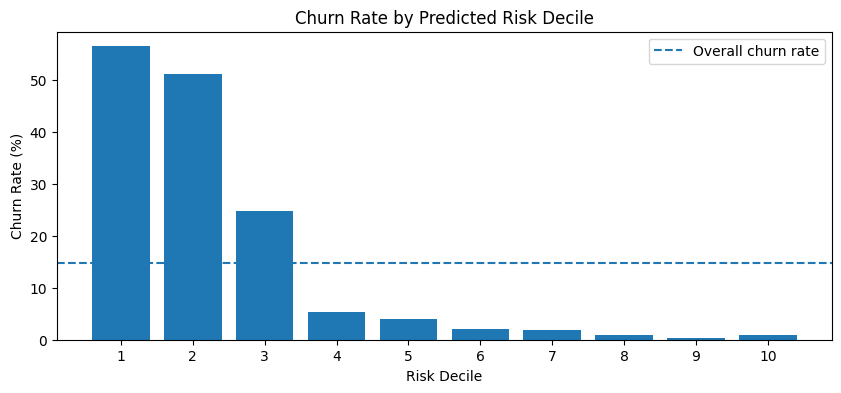

In [30]:
# Plotting churn rate by risk decile

plt.figure(figsize=(10, 4))

plt.bar(lift_table.index.astype(str), lift_table["churn_rate"] * 100)

plt.axhline(
    overall_churn_rate * 100,
    linestyle="--",
    label="Overall churn rate"
)

plt.title("Churn Rate by Predicted Risk Decile")
plt.xlabel("Risk Decile")
plt.ylabel("Churn Rate (%)")
plt.legend()
plt.show()

In [31]:
# Saving model comparison and lift table

model_comparison.to_csv(
    OUTPUT_DIR / "04_model_comparison.csv",
    index=False
)

lift_table.to_csv(
    OUTPUT_DIR / "04_lift_table.csv"
)

cm_df.to_csv(
    OUTPUT_DIR / "04_confusion_matrix.csv"
)

print("Saved model evaluation outputs successfully.")

Saved model evaluation outputs successfully.


In [32]:
# Extracting feature names after preprocessing

encoded_cat_cols = (
    champion_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(safe_categorical_cols)
)

all_feature_names = list(safe_numeric_cols) + list(encoded_cat_cols)

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": champion_model.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

,feature,importance
6,inactive_months_obs,0.210842
7,active_month_rate_obs,0.191264
2,active_months_obs,0.128600
1,total_flights_obs,0.108069
3,total_distance_obs,0.104104
4,total_points_accumulated_obs,0.103955
8,avg_flights_per_active_month_obs,0.079256
5,total_points_redeemed_obs,0.033783
62,enrollment_type_2018 Promotion,0.006314
9,clv,0.005819


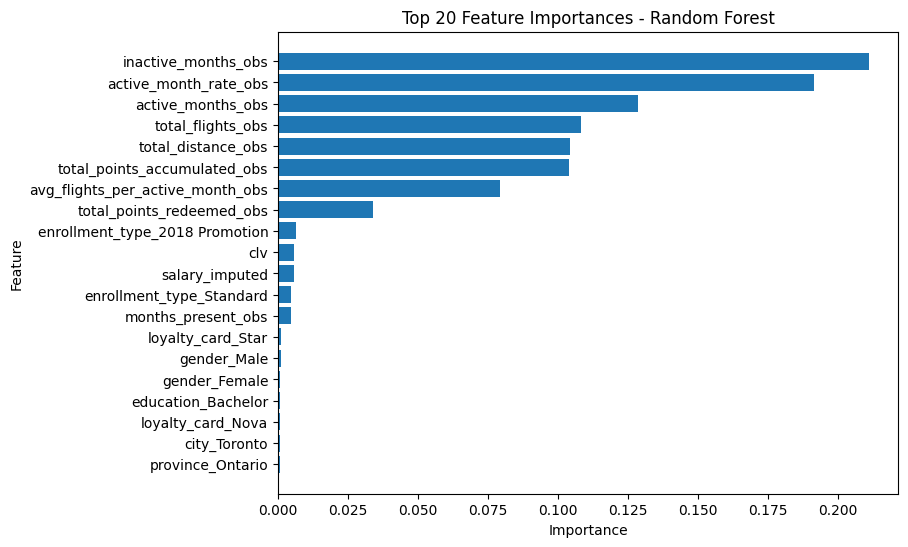

In [33]:
# Plotting top 20 feature importances

top_features = feature_importance.head(20).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Observation:
Feature importance shows that the Random Forest model is mainly driven by behavioral activity features such as inactive months, active month rate, active months, total flights, distance, and accumulated points during the observation period. Demographic variables such as gender, city, and province have much lower importance. This is a positive sign because the model is learning meaningful customer engagement patterns rather than relying mainly on static profile attributes.

In [34]:
# Saving feature importance output

feature_importance.to_csv(
    OUTPUT_DIR / "04_feature_importance.csv",
    index=False
)

print("Saved feature importance successfully.")

Saved feature importance successfully.


In [35]:
# Summarizing Notebook 04 results

print("NB04 SUMMARY")
print("-" * 50)

print("Leakage issue found:")
print("Initial model showed near-perfect performance, indicating temporal leakage.")

print("\nLeakage-safe setup:")
print("Observation period: Jan 2017 to Jun 2018")
print("Target period: Jul 2018 to Dec 2018")
print("Target: No flights in future 6-month period")

print("\nChampion model:")
print(champion_name)

print("\nChampion model test metrics:")
print("Accuracy:", round(safe_rf_metrics["test_accuracy"], 3))
print("Precision:", round(safe_rf_metrics["test_precision"], 3))
print("Recall:", round(safe_rf_metrics["test_recall"], 3))
print("F1-score:", round(safe_rf_metrics["test_f1"], 3))
print("ROC-AUC:", round(safe_rf_metrics["test_roc_auc"], 3))
print("PR-AUC:", round(safe_rf_metrics["test_pr_auc"], 3))

print("\nLift result:")
print("Top decile churn rate:", round(lift_table.loc[1, "churn_rate"] * 100, 1), "%")
print("Top decile lift:", round(lift_table.loc[1, "lift"], 2), "x")

print("\nMost important feature:")
print(feature_importance.iloc[0]["feature"])

print("\nNotebook 04 completed successfully.")

NB04 SUMMARY
--------------------------------------------------
Leakage issue found:
Initial model showed near-perfect performance, indicating temporal leakage.

Leakage-safe setup:
Observation period: Jan 2017 to Jun 2018
Target period: Jul 2018 to Dec 2018
Target: No flights in future 6-month period

Champion model:
Safe Random Forest

Champion model test metrics:
Accuracy: 0.825
Precision: 0.452
Recall: 0.893
F1-score: 0.6
ROC-AUC: 0.897
PR-AUC: 0.536

Lift result:
Top decile churn rate: 56.4 %
Top decile lift: 3.82 x

Most important feature:
inactive_months_obs

Notebook 04 completed successfully.
